# Portfolio Construction Codebook

This notebook implements the empirical comparison between mean-variance optimization and equal risk contribution using the common 7-asset universe:

- ACWI
- TLT
- LQD
- TIP
- DBC
- VNQ
- QAI

The workflow uses simple daily returns from closing prices, monthly rebalancing, a 252-trading-day estimation window, and long-only fully invested portfolios.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

from helper_func import run_analysis

In [2]:
DATA_DIR = Path('.')
results = run_analysis(DATA_DIR)
output_dir = results['output_dir']
output_dir

PosixPath('output')

### Performance Summary

In [3]:
results['summary_formatted']

,Annual Return,Volatility,Sharpe Ratio,Max Drawdown,Average Monthly Turnover,Effective N,Gross Leverage
Strategy,,,,,,,
Mean-Variance,8.15%,16.31%,0.499734,-26.23%,16.03%,1.202070,1.0
Risk Parity,1.36%,7.00%,0.194438,-20.42%,2.05%,5.812607,1.0


### Turnover, Diversification, Weight Stability

In [4]:
results['instability_formatted']

,Average Turnover,Median Turnover,Weight Std Dev,Average Effective N
Strategy,,,,
Mean-Variance,16.03%,0.00%,25.16%,1.202070
Risk Parity,2.05%,1.35%,2.37%,5.812607


### Sensitivity to Estimation Error

In [5]:
results['sensitivity_formatted']
# Bootstrap resampling is used here as a practical proxy for estimation error.

,Mean L1 Weight Change,90th Pct L1 Weight Change
Strategy,,
Mean-Variance,94.62%,200.00%
Risk Parity,5.94%,9.90%


### Parameter Instability in Rolling Inputs

In [6]:
results['parameter_instability_formatted']

,Average Annualized Mean Std,Average Annualized Vol Std
Across Assets,11.49%,4.37%


### Portfolio Weights

In [17]:
# MVO
results['mvo_result'].target_weights.tail().round(3)

,ACWI,TLT,LQD,TIP,DBC,VNQ,QAI
2025-11-28,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-12-31,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-01-30,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-02-27,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-03-31,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [18]:
# Risk parity
results['erc_result'].target_weights.tail().round(3)

,ACWI,TLT,LQD,TIP,DBC,VNQ,QAI
2025-11-28,0.071,0.116,0.161,0.295,0.124,0.067,0.168
2025-12-31,0.070,0.117,0.162,0.294,0.125,0.069,0.163
2026-01-30,0.071,0.118,0.166,0.297,0.117,0.071,0.161
2026-02-27,0.071,0.122,0.169,0.302,0.109,0.070,0.157
2026-03-31,0.071,0.122,0.165,0.297,0.118,0.072,0.155


### Charts

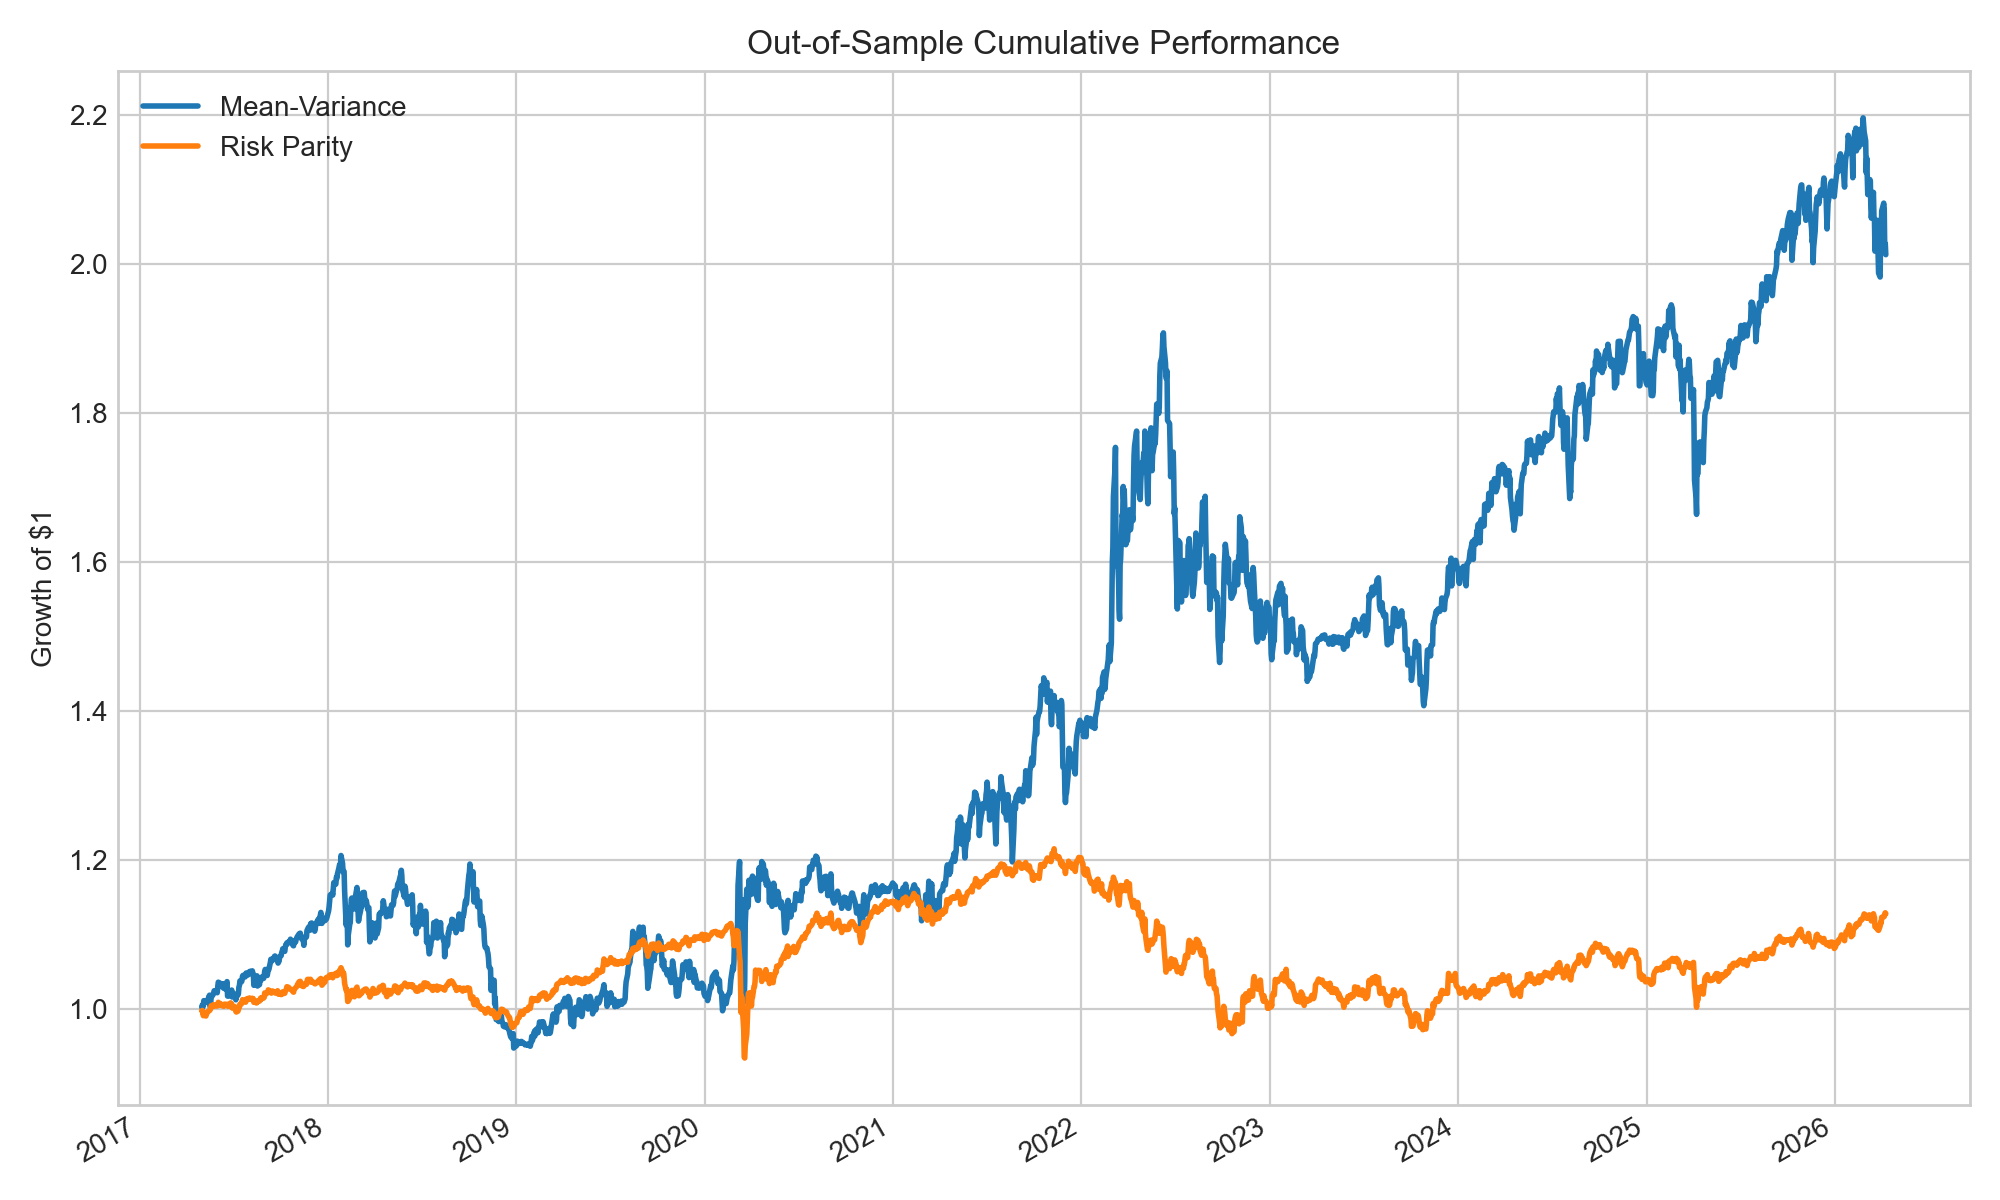

In [9]:
display(Image(filename=str(output_dir / 'cumulative_returns.png')))

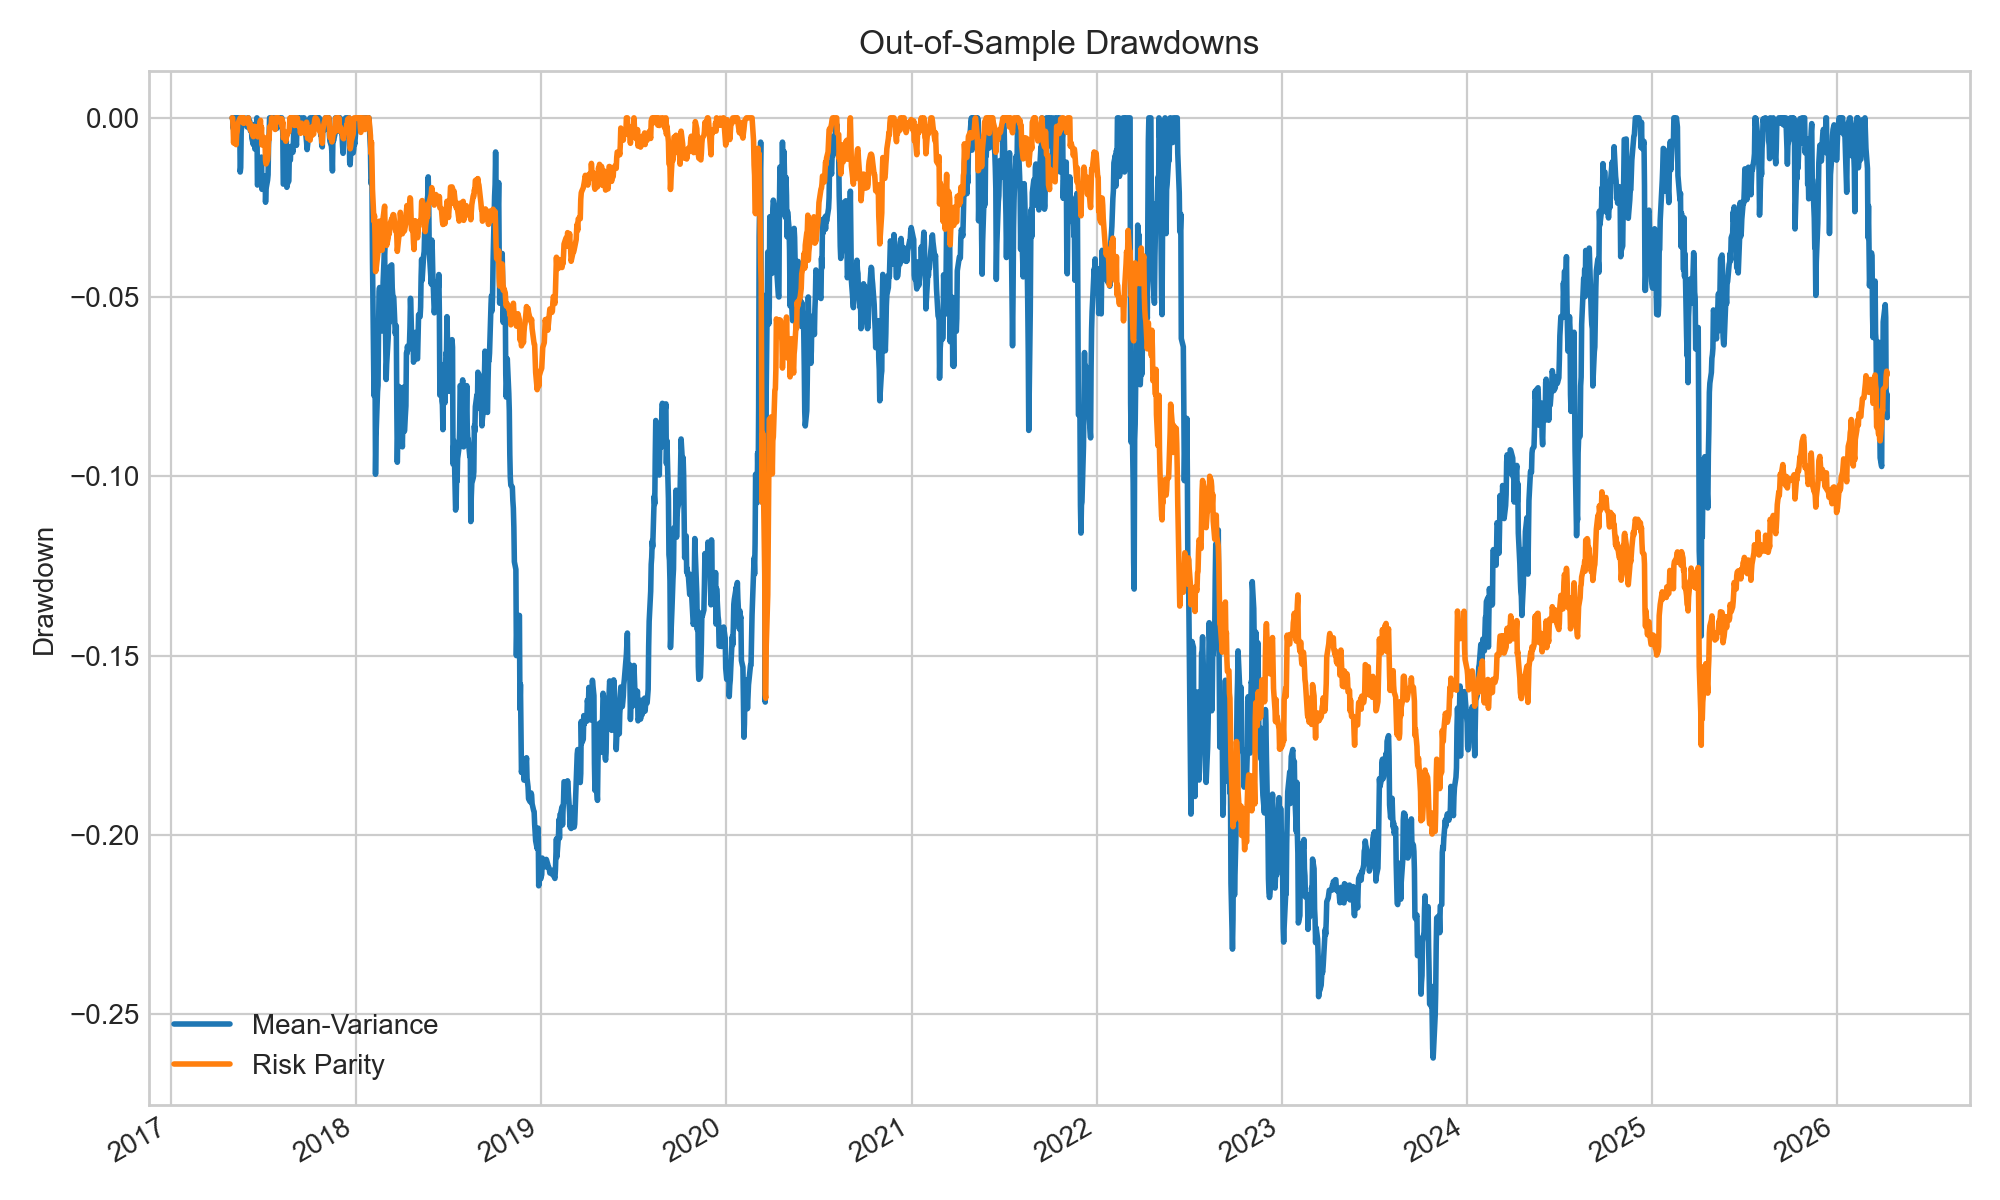

In [10]:
display(Image(filename=str(output_dir / 'drawdowns.png')))

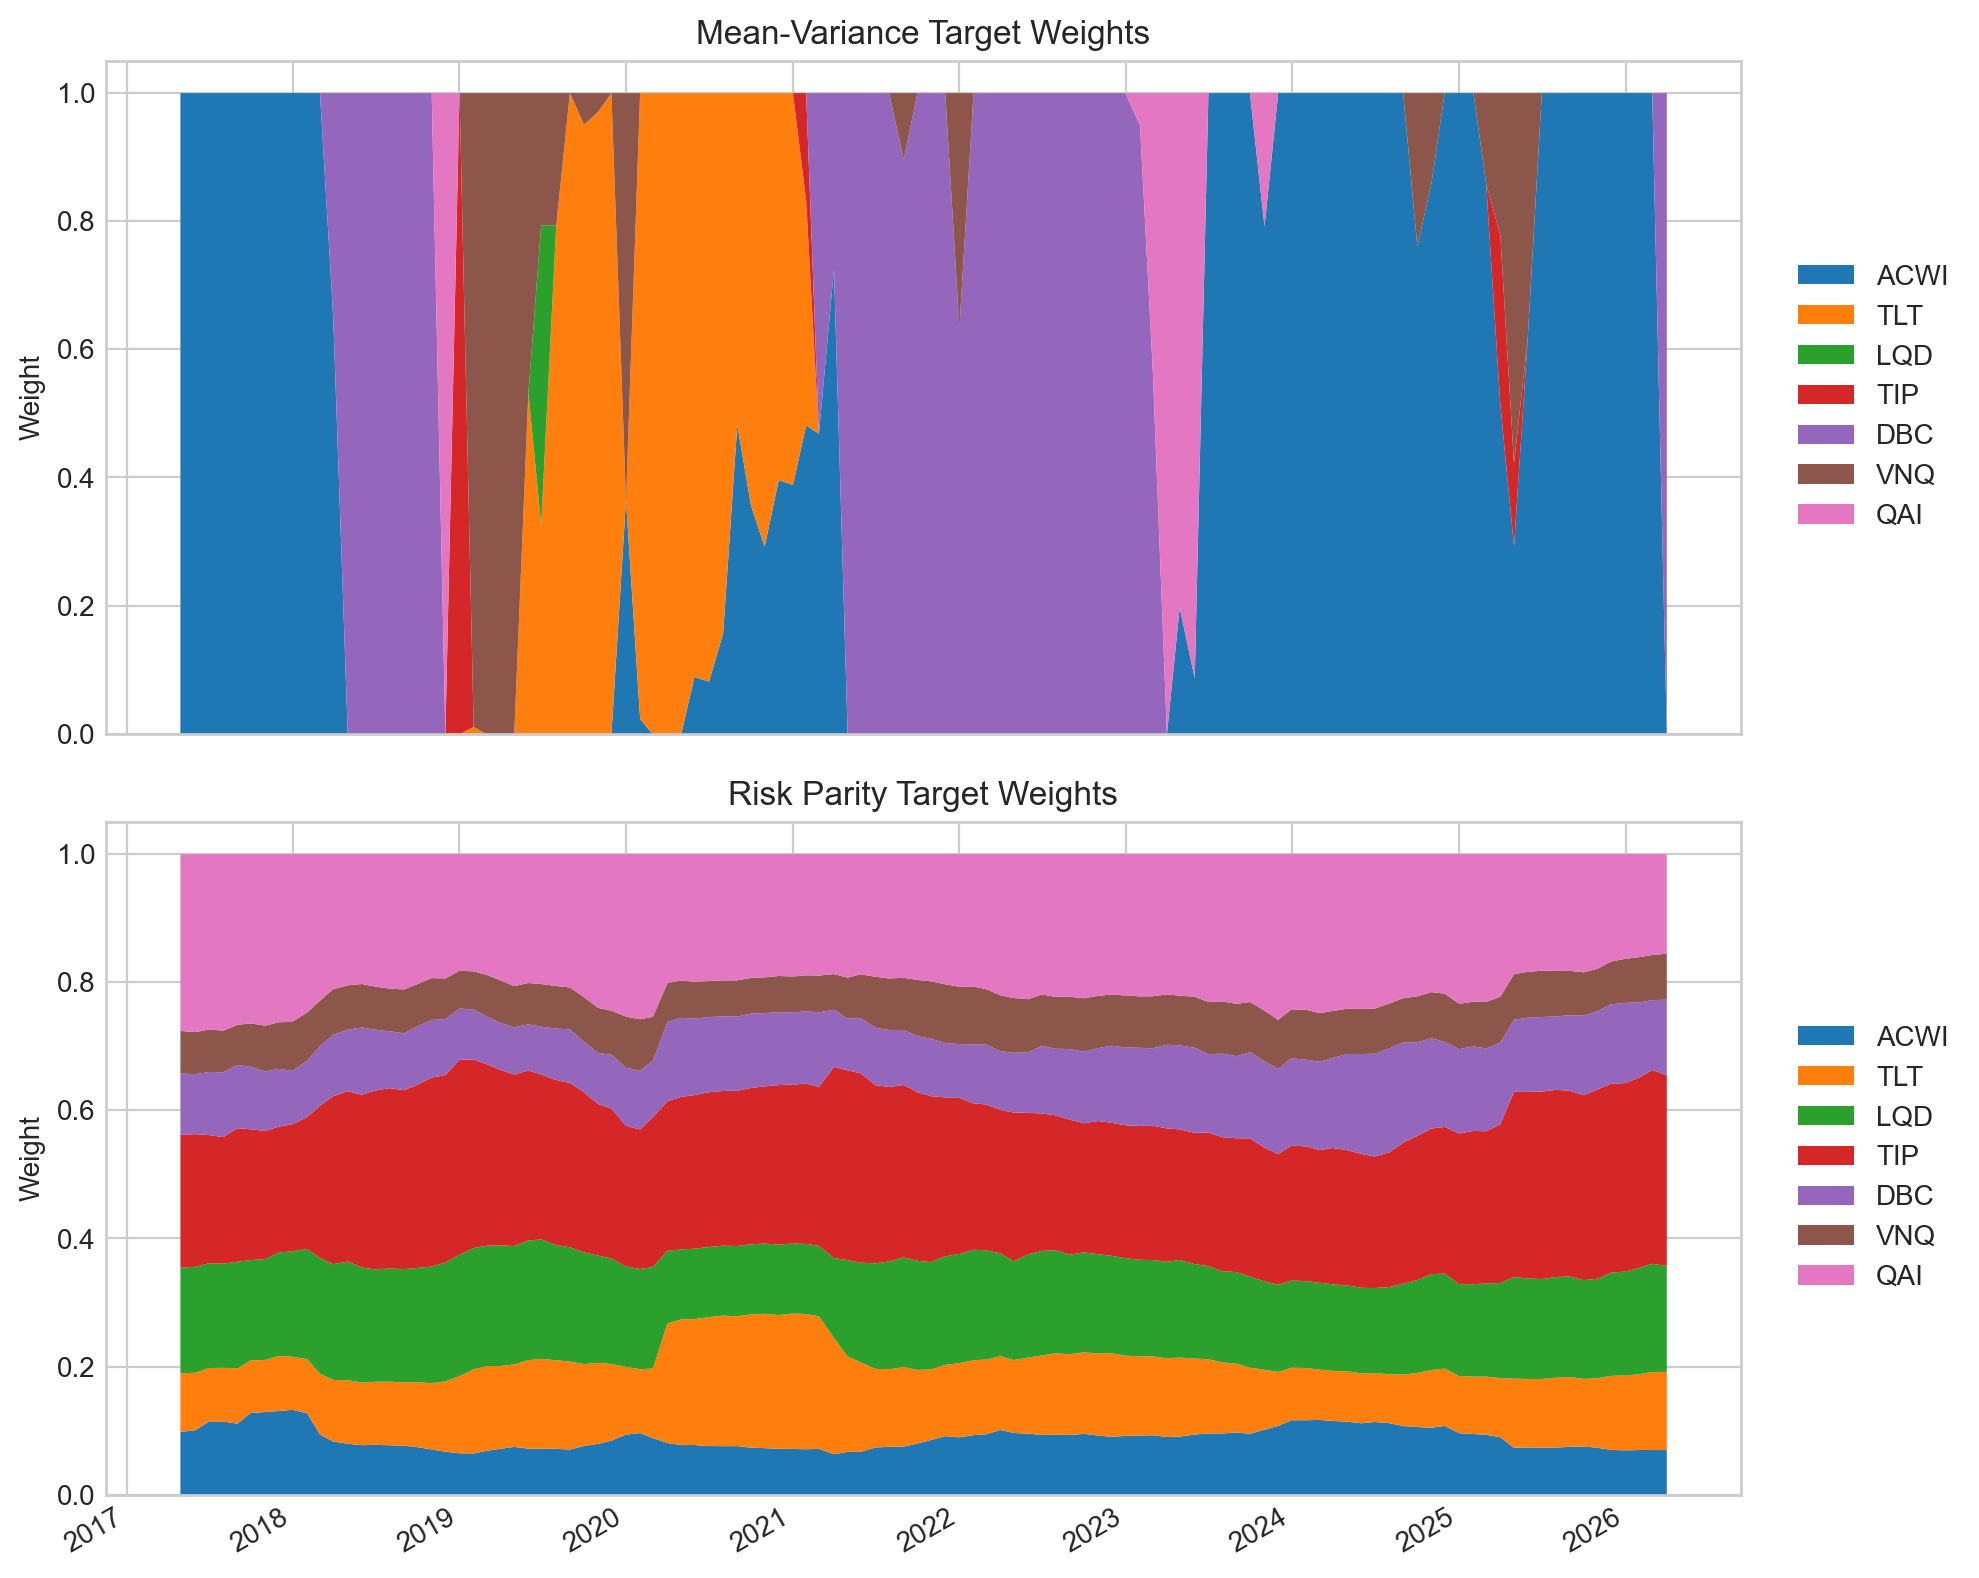

In [11]:
display(Image(filename=str(output_dir / 'weights.png')))